In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
df = pd.read_csv("Risk_Alert.csv")

In [44]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [45]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [46]:
df.drop(columns=['customer_id'], inplace=True)

In [47]:
df.head()

,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [48]:
df.head(50)

,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0
5,53.0,Female,East,Salaried,38733.0,691.0,0.625,0,2.1,68,17693.0,0,0,0,59,2025-10-10,21350,0
6,26.0,Male,Central,Self-Employed,56641.0,611.0,0.115,0,0.7,76,38589.0,1,1,3,81,2025-09-04,15676,0
7,34.0,Female,Central,Salaried,40835.0,772.0,0.294,0,0.6,72,29414.0,1,0,1,52,2025-12-01,16426,0
8,22.0,Male,South,Salaried,19967.0,668.0,0.299,0,11.1,52,9380.0,0,1,2,15,2025-11-14,16267,0
9,29.0,Male,East,Retired,45896.0,705.0,0.303,0,10.0,24,33487.0,1,1,3,143,2025-10-25,39934,0


In [49]:
from sklearn.impute import KNNImputer

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4460 non-null   float64
 1   gender                     4600 non-null   object 
 2   region                     4498 non-null   object 
 3   employment_type            4456 non-null   object 
 4   annual_income_inr          4434 non-null   float64
 5   credit_score               4384 non-null   float64
 6   credit_utilization_ratio   4453 non-null   float64
 7   missed_payments_12m        4600 non-null   int64  
 8   avg_late_payment_days      4600 non-null   float64
 9   monthly_transaction_count  4600 non-null   int64  
 10  monthly_spend_inr          4471 non-null   float64
 11  cash_advance_count_6m      4600 non-null   int64  
 12  complaints_last_6m         4600 non-null   int64  
 13  failed_login_attempts_3m   4600 non-null   int64

In [51]:
df.head()

,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [52]:

df = pd.read_csv("risk_alert.csv")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])
print(df.isnull().sum())

customer_id                    0
age                            0
gender                         0
region                       102
employment_type              144
annual_income_inr              0
credit_score                   0
credit_utilization_ratio       0
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr              0
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


In [53]:
cat_cols = df.select_dtypes(include=['object']).columns


In [54]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = imputer.fit_transform(df[cat_cols])

In [55]:
df.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

In [56]:
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt 

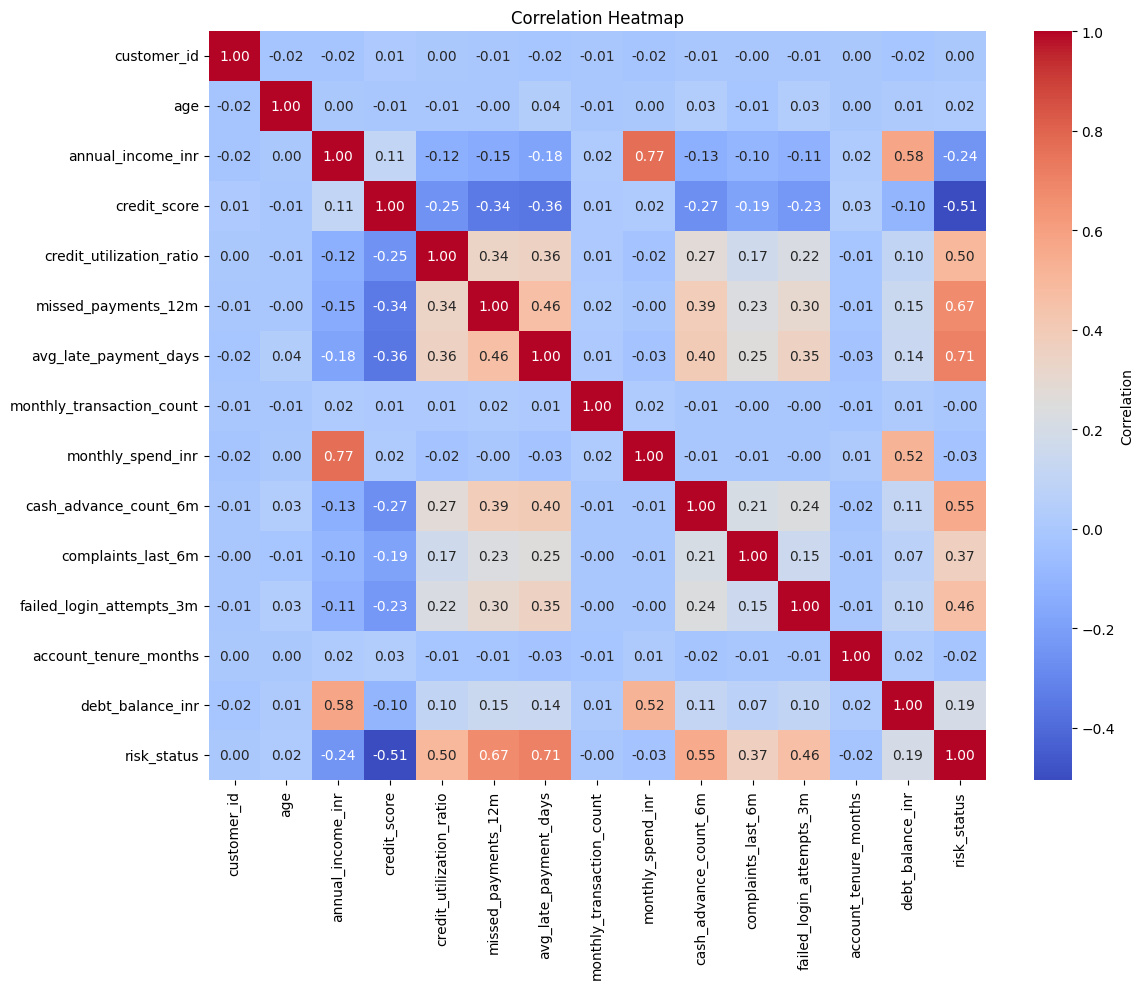

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [59]:
x = df.drop(columns=['risk_status'], axis=1)
y = df['risk_status']

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


In [62]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [63]:
y_pred = model.predict(x_test)


In [64]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)




Confusion Matrix:
[[792   4]
 [  7 117]]


In [65]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)




Accuracy : 0.9880434782608696
Precision: 0.9669421487603306
Recall   : 0.9435483870967742
F1-Score : 0.9551020408163265


In [66]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       796
         1.0       0.97      0.94      0.96       124

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



In [67]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

True Negative (TN): 792
False Positive (FP): 4
False Negative (FN): 7
True Positive (TP): 117


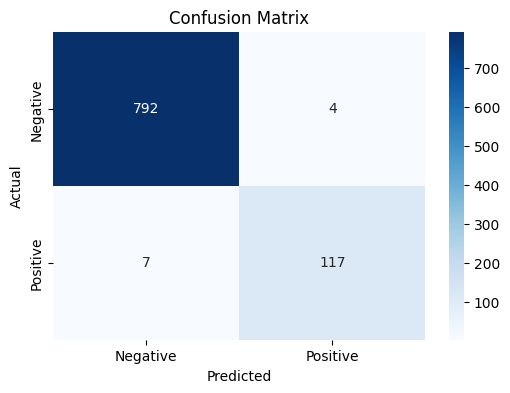

In [68]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, recall_score, roc_auc_score

# Features and target
X = df.drop('risk_status', axis=1)
y = df['risk_status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Baseline Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, y_prob)

print("Baseline Results")
print("Recall :", baseline_recall)
print("F1 Score :", baseline_f1)
print("AUC ROC :", baseline_auc)

Baseline Results
Recall : 0.9369369369369369
F1 Score : 0.9497716894977168
AUC ROC : 0.9990088976491943


e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [70]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN


In [71]:
def evaluate_model(X_train_res, y_train_res, X_test, y_test):

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return recall, f1, auc




In [72]:
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(x_train, y_train)

under_recall, under_f1, under_auc = evaluate_model(
    X_under,
    y_under,
    x_test,
    y_test
)

e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(x_train, y_train)

over_recall, over_f1, over_auc = evaluate_model(
    X_over,
    y_over,
    x_test,
    y_test
)

e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(x_train, y_train)

smote_recall, smote_f1, smote_auc = evaluate_model(
    X_smote,
    y_smote,
    x_test,
    y_test
)

e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(x_train, y_train)

adasyn_recall, adasyn_f1, adasyn_auc = evaluate_model(
    X_adasyn,
    y_adasyn,
    x_test,
    y_test
)

e:\Rnw\dataprofiler\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Original",
        "Under-Sampling",
        "Over-Sampling",
        "SMOTE",
        "ADASYN"
    ],

    "Recall": [
        baseline_recall,
        under_recall,
        over_recall,
        smote_recall,
        adasyn_recall
    ],

    "F1-Score": [
        baseline_f1,
        under_f1,
        over_f1,
        smote_f1,
        adasyn_f1
    ],

    "AUC-ROC": [
        baseline_auc,
        under_auc,
        over_auc,
        smote_auc,
        adasyn_auc
    ]
})

print(results)

           Method    Recall  F1-Score   AUC-ROC
0        Original  0.936937  0.949772  0.999009
1  Under-Sampling  0.369369  0.144876  0.434259
2   Over-Sampling  0.333333  0.134545  0.419214
3           SMOTE  0.378378  0.143101  0.421430
4          ADASYN  0.387387  0.165703  0.472555


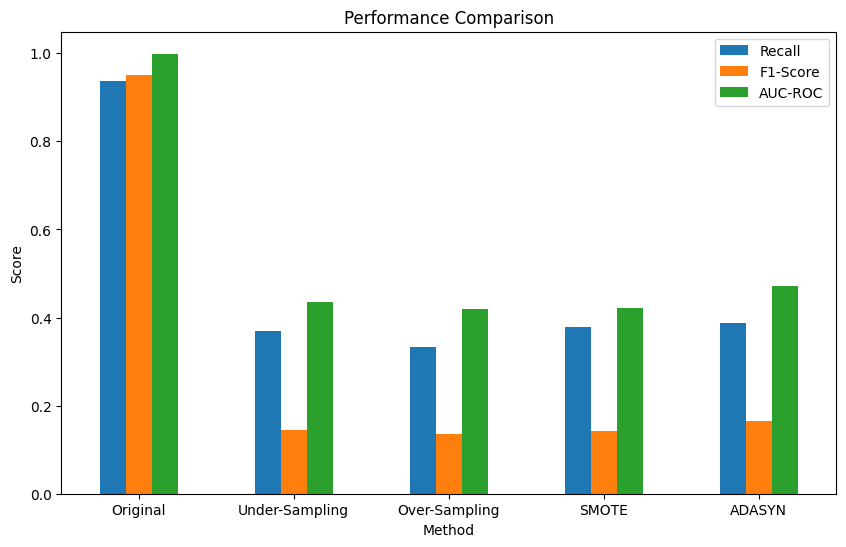

In [77]:
import matplotlib.pyplot as plt

results.set_index("Method").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

dt_train_pred = dt.predict(x_train)
dt_test_pred = dt.predict(x_test)

print("Decision Tree Accuracy (Train):",
      accuracy_score(y_train, dt_train_pred))

print("Decision Tree Accuracy (Test):",
      accuracy_score(y_test, dt_test_pred))

print(classification_report(y_test, dt_test_pred))

Decision Tree Accuracy (Train): 1.0
Decision Tree Accuracy (Test): 0.7597826086956522
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       809
         1.0       0.09      0.11      0.10       111

    accuracy                           0.76       920
   macro avg       0.48      0.48      0.48       920
weighted avg       0.78      0.76      0.77       920



In [79]:
train_acc_dt = accuracy_score(y_train, dt_train_pred)
test_acc_dt = accuracy_score(y_test, dt_test_pred)

print("Training Accuracy :", train_acc_dt)
print("Testing Accuracy  :", test_acc_dt)

if train_acc_dt - test_acc_dt > 0.05:
    print("Decision Tree is Overfitting")
else:
    print("No Significant Overfitting")

Training Accuracy : 1.0
Testing Accuracy  : 0.7597826086956522
Decision Tree is Overfitting


In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

rf_train_pred = rf.predict(x_train)
rf_test_pred = rf.predict(x_test)

print("Random Forest Train Accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("Random Forest Test Accuracy:",
      accuracy_score(y_test, rf_test_pred))

print(classification_report(y_test, rf_test_pred))

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.8793478260869565
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94       809
         1.0       0.00      0.00      0.00       111

    accuracy                           0.88       920
   macro avg       0.44      0.50      0.47       920
weighted avg       0.77      0.88      0.82       920



e:\Rnw\dataprofiler\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Rnw\dataprofiler\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Rnw\dataprofiler\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [81]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, dt_test_pred),
        accuracy_score(y_test, rf_test_pred)
    ]
})

print(comparison)

           Model  Train Accuracy  Test Accuracy
0  Decision Tree             1.0       0.759783
1  Random Forest             1.0       0.879348


In [82]:
from sklearn.model_selection import RandomizedSearchCV

dt_params = {
    'max_depth': [3,5,10,15,None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,8],
    'criterion': ['gini','entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

dt_random.fit(x_train, y_train)

print("Best DT Params:")
print(dt_random.best_params_)

Best DT Params:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}


In [83]:
rf_params = {
    'n_estimators': [100,200,300,500],
    'max_depth': [5,10,15,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(x_train, y_train)

print("Best RF Params:")
print(rf_random.best_params_)

Best RF Params:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}


In [84]:
from sklearn.model_selection import GridSearchCV

grid_params = {
    'n_estimators': [
        rf_random.best_params_['n_estimators']-100,
        rf_random.best_params_['n_estimators'],
        rf_random.best_params_['n_estimators']+100
    ],
    'max_depth': [
        rf_random.best_params_['max_depth']
    ],
    'min_samples_split': [
        rf_random.best_params_['min_samples_split']
    ],
    'min_samples_leaf': [
        rf_random.best_params_['min_samples_leaf']
    ]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    grid_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [85]:
best_rf = grid_rf.best_estimator_

untuned_pred = rf.predict(x_test)
tuned_pred = best_rf.predict(x_test)

comparison = pd.DataFrame({
    "Model": ["Untuned RF", "Tuned RF"],
    "Accuracy": [
        accuracy_score(y_test, untuned_pred),
        accuracy_score(y_test, tuned_pred)
    ],
    "Recall": [
        recall_score(y_test, untuned_pred),
        recall_score(y_test, tuned_pred)
    ],
    "F1 Score": [
        f1_score(y_test, untuned_pred),
        f1_score(y_test, tuned_pred)
    ]
})

print(comparison)

        Model  Accuracy  Recall  F1 Score
0  Untuned RF  0.879348     0.0       0.0
1    Tuned RF  0.879348     0.0       0.0


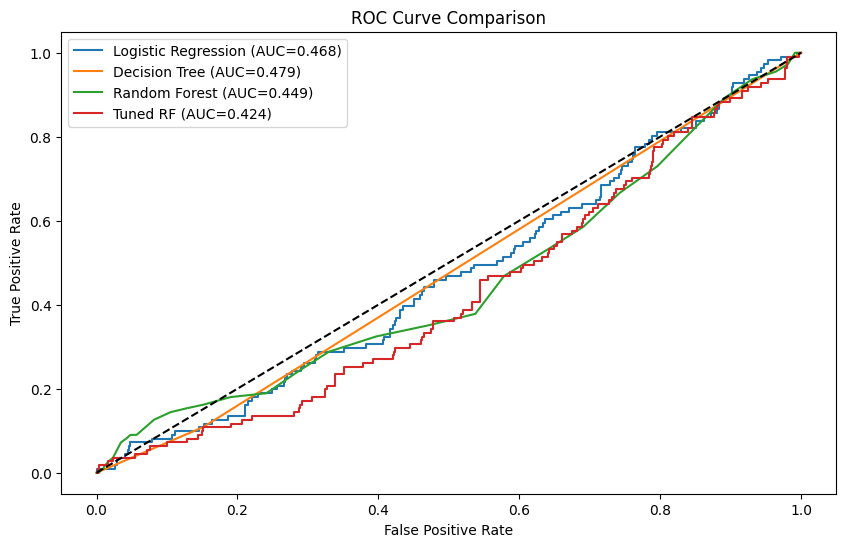

In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Tuned RF": best_rf
}

plt.figure(figsize=(10,6))

for name, model in models.items():

    y_prob = model.predict_proba(x_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [87]:
for name, model in models.items():

    y_prob = model.predict_proba(x_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)

    print(f"{name}: {auc:.4f}")

Logistic Regression: 0.4679
Decision Tree: 0.4787
Random Forest: 0.4491
Tuned RF: 0.4237


In [88]:
results = []

for name, model in models.items():

    pred = model.predict(x_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

final_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Recall",
        "F1 Score"
    ]
)

print(final_results.sort_values(
    by="Recall",
    ascending=False
))

                 Model  Accuracy    Recall  F1 Score
1        Decision Tree  0.759783  0.108108  0.097959
0  Logistic Regression  0.773913  0.099099  0.095652
2        Random Forest  0.879348  0.000000  0.000000
3             Tuned RF  0.879348  0.000000  0.000000
